# Chemical Integrity Digital Twin

End-to-end demo of the NeqSim chemistry stack on an anonymised tieback case:
electrolyte scale, mechanistic CO2 corrosion, closed-loop deposition, packed-bed scavenger.


In [1]:
import os, sys
from pathlib import Path

def find_project_root():
    env = os.environ.get('NEQSIM_PROJECT_ROOT')
    candidates = [Path(env).resolve()] if env else []
    candidates += [Path.cwd().resolve()] + list(Path.cwd().resolve().parents)
    for c in candidates:
        if (c / 'pom.xml').exists() and (c / 'devtools' / 'neqsim_dev_setup.py').exists():
            return c
    raise RuntimeError('Project root not found')

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / 'devtools'))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_init(project_root=ROOT, recompile=False, verbose=False)
ns = neqsim_classes(ns)
import matplotlib.pyplot as plt
import numpy as np


All NeqSim classes imported OK


## 1. Electrolyte scale prediction


In [2]:
ESC = ns.JClass('neqsim.process.chemistry.scale.ElectrolyteScaleCalculator')
calc = ESC()
calc.setTemperatureCelsius(80.0).setPressureBara(120.0).setPH(6.5).setCO2PartialPressureBar(4.0)
calc.setCations(1500.0, 5.0, 80.0, 800.0, 12000.0, 400.0, 0.0)
calc.setAnions(20000.0, 100.0, 400.0, 0.0)
calc.calculate()
print('Ionic strength (mol/kg):', round(calc.getIonicStrength(), 3))
print('SI(CaCO3):', round(calc.getCaCO3SaturationIndex(), 3))
print('SI(BaSO4):', round(calc.getBaSO4SaturationIndex(), 3))
print('SI(CaSO4):', round(calc.getCaSO4SaturationIndex(), 3))
print('SI(SrSO4):', round(calc.getSrSO4SaturationIndex(), 3))


Ionic strength (mol/kg): 0.696
SI(CaCO3): -1.072
SI(BaSO4): 0.795
SI(CaSO4): -1.199
SI(SrSO4): -1.046


## 2. Mechanistic CO2 corrosion vs inhibitor dose


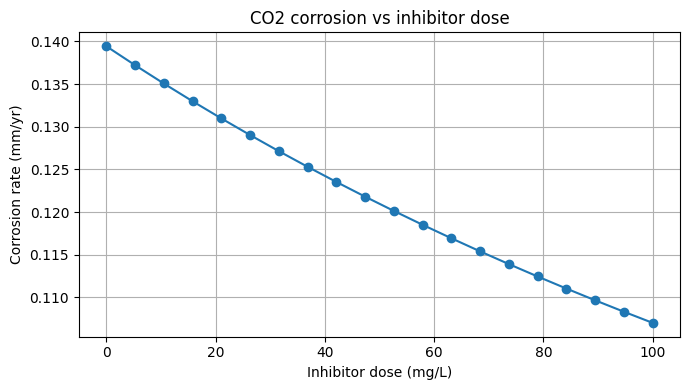

In [3]:
Iso = ns.JClass('neqsim.process.chemistry.corrosion.LangmuirInhibitorIsotherm')
MCM = ns.JClass('neqsim.process.chemistry.corrosion.MechanisticCorrosionModel')
iso = Iso()
doses = np.linspace(0, 100, 20)
rates = []
for d in doses:
    m = MCM().setTemperatureCelsius(60.0).setTotalPressureBara(80.0)
    m.setGasComposition(0.05, 0.0).setWaterChemistry(5.5, 100.0, 0.5)
    m.setFlow(2.0, 0.15, 1000.0, 1.0e-3).setInhibitor(iso, float(d)).evaluate()
    rates.append(m.getInhibitedRateMmYr())
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(doses, rates, 'o-')
ax.set_xlabel('Inhibitor dose (mg/L)')
ax.set_ylabel('Corrosion rate (mm/yr)')
ax.set_title('CO2 corrosion vs inhibitor dose')
ax.grid(True)
plt.tight_layout()
plt.show()


## 3. Closed-loop deposition along a 1 km flowline


Iterations: 1 converged: True
Final effective diameter (m): 0.2


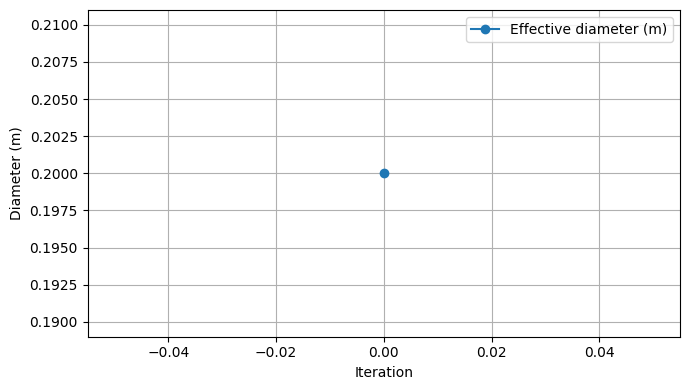

In [4]:
fluid = ns.SystemSrkEos(308.15, 80.0)
for c, x in [('methane', 0.85), ('CO2', 0.04), ('water', 0.11)]:
    fluid.addComponent(c, x)
fluid.setMixingRule('classic')
Stream = ns.JClass('neqsim.process.equipment.stream.Stream')
stream = Stream('feed', fluid)
stream.setFlowRate(50000.0, 'kg/hr')
stream.run()
Pipe = ns.JClass('neqsim.process.equipment.pipeline.PipeBeggsAndBrills')
pipe = Pipe('flowline', stream)
pipe.setLength(1000.0); pipe.setDiameter(0.2)
Acc = ns.JClass('neqsim.process.chemistry.scale.ScaleDepositionAccumulator')
acc = Acc(pipe).setBrineChemistry(1500.0, 400.0, 100.0, 5.0, 12000.0, 35000.0)
acc.setpHAndCo2(6.5, 4.0).setInhibitorEfficiency(0.7).setServiceYears(5.0)
Solver = ns.JClass('neqsim.process.chemistry.scale.ClosedLoopDepositionSolver')
solver = Solver(pipe, acc).setMaxIterations(8).setToleranceM(1e-4)
solver.solve()
diameters = list(solver.getDiameterHistoryM())
print('Iterations:', solver.getIterationsTaken(), 'converged:', solver.isConverged())
print('Final effective diameter (m):', round(solver.getFinalEffectiveDiameterM(), 4))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(diameters)), diameters, 'o-', label='Effective diameter (m)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Diameter (m)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


## 4. Packed-bed H2S scavenger breakthrough


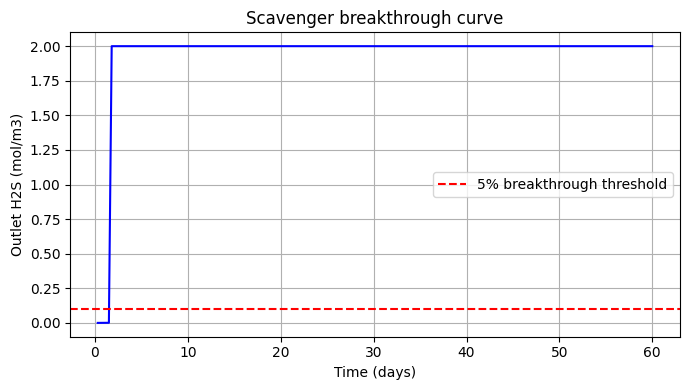

Breakthrough time (days): 1.8
Total H2S removed (kg): 44.16


In [5]:
Bed = ns.JClass('neqsim.process.chemistry.scavenger.PackedBedScavengerReactor')
bed = Bed().setGeometry(0.5, 2.0, 0.4).setMedia(5.0, 1100.0, 1.0)
bed.setRateConstant(8.0).setFeed(2.0, 0.005)
bed.setDiscretisation(40, 200).setSimulationTime(60 * 24 * 3600.0, 0.05)
bed.evaluate()
t = np.array(list(bed.getTimeSeriesS())) / (24 * 3600.0)
c = np.array(list(bed.getOutletConcentrationProfile()))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, c, 'b-')
ax.axhline(0.05 * 2.0, color='r', linestyle='--', label='5% breakthrough threshold')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Outlet H2S (mol/m3)')
ax.set_title('Scavenger breakthrough curve')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()
print('Breakthrough time (days):', round(bed.getBreakthroughTimeS() / 86400.0, 2))
print('Total H2S removed (kg):', round(bed.getTotalH2sRemovedKg(), 2))
